# Task 1: Problem Identification
The dataset represents an Image Classification problem.

This is because each image in the dataset is assigned to a single category or class, such as normal or scratch, as shown in the labels.csv file. The goal of the model is to analyze the entire image and predict which class it belongs to.

Image classification is the correct problem type because:

---> Each image has one label
---> The dataset does not contain bounding boxes for objects
---> The dataset does not contain pixel-level masks for segmentation
---> The task focuses on identifying the overall condition of the image

Therefore, the dataset is best suited for an image classification task using a Convolutional Neural Network (CNN).

# Task 2: Dataset Exploration

##  Number of Classes
The dataset contains 4 classes:
1. normal
2. scratch
3. dent
4. stain

## Number of Images per Class

class                         Number of Images
normal                              120
sratch                              120
dent                                120
stain                               120

Total Images: 480

## Sample Images from Each Class
The dataset includes images showing different surface conditions:
1. normal --> surface without defects
2. scratch --> visible scratches on the surface
3. dent --> dented or pressed surface areas
4. stain --> stained or marked surfaces

## Image Dimensions
All images have the same dimensions:
--> 96 × 96 pixels
--> RGB color images
This consistent image size is useful for training CNN models because all images can be processed uniformly.

## Dataset Imbalance Analysis
The dataset is balanced because each class contains the same number of images (120 images per class).

A balanced dataset is beneficial because:

--> The model gets equal learning opportunities for every class
--> It reduces bias toward one specific category
--> It generally improves classification performance
Therefore, no additional balancing techniques are required for this dataset.


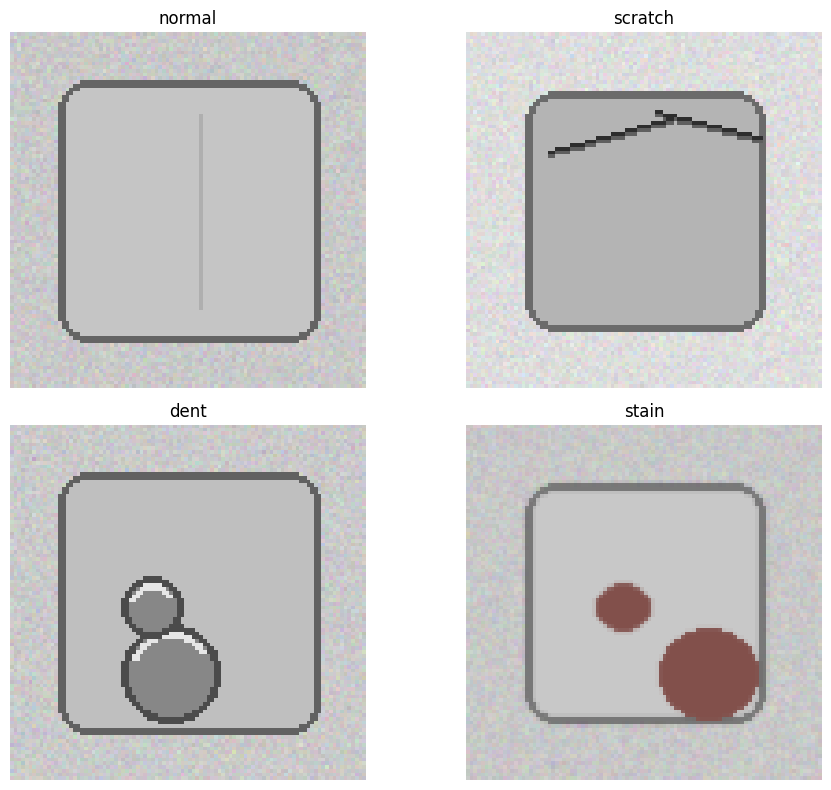

In [11]:
# Sample Images from Each Class
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
import random

# Load labels
df = pd.read_csv("labels.csv")

classes = df['class'].unique()

plt.figure(figsize=(10,8))

for i, cls in enumerate(classes):
    sample = df[df['class'] == cls].sample(1).iloc[0]

    img = mpimg.imread(sample['filename'])

    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.tight_layout()
plt.show()

# Task 3: Image Preprocessing

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image size
IMG_SIZE = (96, 96)

# Batch size
BATCH_SIZE = 32

# Data augmentation + normalization
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

# Only normalization for testing
test_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Training data
train_data = train_datagen.flow_from_directory(
    "images",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

# Testing data
test_data = test_datagen.flow_from_directory(
    "images",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 384 images belonging to 4 classes.
Found 96 images belonging to 4 classes.


# Preprocessing Steps

## Resizing Images
All images were resized to 96 × 96 pixels so that every image has a consistent size for CNN training.

## Normalizing Pixel Values
Pixel values were normalized using:
rescale = 1./255

This converts pixel values from the range 0–255 to 0–1, which helps the model train faster and more efficiently.

## Train-Test Split
The dataset was divided into:
--> 80% training data
--> 20% testing/validation data
using: 
validation_split = 0.2

## Data Augmentation
Data augmentation techniques were applied to improve model generalization and reduce overfitting. The following transformations were used:
--> Rotation
--> zooming
--> Horizontal flipping
These transformations create slightly modified versions of images during training.

# Task 4: CNN Model Creation

In [12]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense

# Create CNN model
model = Sequential()

# Convolution + Activation + Pooling
model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(96,96,3)
))

model.add(MaxPooling2D(pool_size=(2,2)))

# Second convolution block
model.add(Conv2D(
    64,
    (3,3),
    activation='relu'
))

model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten layer
model.add(Flatten())

# Dense layer
model.add(Dense(128, activation='relu'))

# Output layer
model.add(Dense(4, activation='softmax'))

# Model summary
model.summary()

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,984,964 (15.20 MB)

 Trainable params: 3,984,964 (15.20 MB)

 Non-trainable params: 0 (0.00 B)

# CNN Model Explanation

## Convolution Layer
The convolution layers extract important image features such as edges, textures, scratches, dents, and patterns.

## Activation Function
The ReLU activation function is used to introduce non-linearity and help the model learn complex image patterns.

## Pooling Layer
MaxPooling layers reduce image dimensions and computational complexity while preserving important features.

## Flatten Layer
The flatten layer converts the 2D feature maps into a 1D vector so it can be passed into dense layers.

## Dense Layer
Dense layers perform classification based on the extracted image features.

## Output Layer
The output layer uses the Softmax activation function to classify images into the four dataset classes:
--> normal
--> scratch
--> dent 
--> stain


# Task 5: Model Training and Evaluation

1. Compile the Model

In [13]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

2. Train the Model

In [14]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 17s 702ms/step - accuracy: 0.2292 - loss: 2.0099 - val_accuracy: 0.2500 - val_loss: 1.3706
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 284ms/step - accuracy: 0.2656 - loss: 1.3714 - val_accuracy: 0.5000 - val_loss: 1.3189
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 277ms/step - accuracy: 0.5312 - loss: 1.2861 - val_accuracy: 0.6771 - val_loss: 1.1732
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 285ms/step - accuracy: 0.5104 - loss: 1.1336 - val_accuracy: 0.6458 - val_loss: 0.9391
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 276ms/step - accuracy: 0.6016 - loss: 0.9234 - val_accuracy: 0.6562 - val_loss: 0.7833
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 342ms/step - accuracy: 0.7005 - loss: 0.7735 - val_accuracy: 0.5312 - val_loss: 0.8885
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 270ms/step - accuracy: 0.7370 - loss: 0.7106 - val_accuracy: 0.7188 - val_loss: 0.6425
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 277ms/step - accuracy: 0.7526 - loss: 0.6014 - val_accuracy: 0

3. Evaluate the Model

In [15]:
loss, accuracy = model.evaluate(test_data)

print("Testing Loss:", loss)
print("Testing Accuracy:", accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.8125 - loss: 0.4378
Testing Loss: 0.4378427565097809
Testing Accuracy: 0.8125


4. Plot Accuracy and Loss Graphs

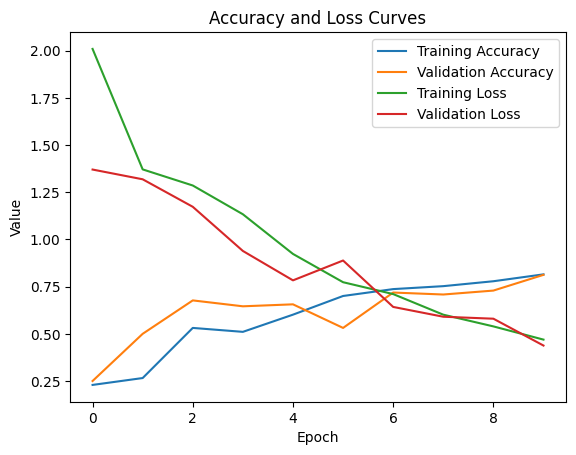

In [20]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

# Loss graph
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Accuracy and Loss Curves")

plt.xlabel("Epoch")
plt.ylabel("Value")

plt.legend()

# Save graph
plt.savefig("results/accuracy_loss_curves.png")

plt.show()

5. Confusion Matrix

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 150ms/step


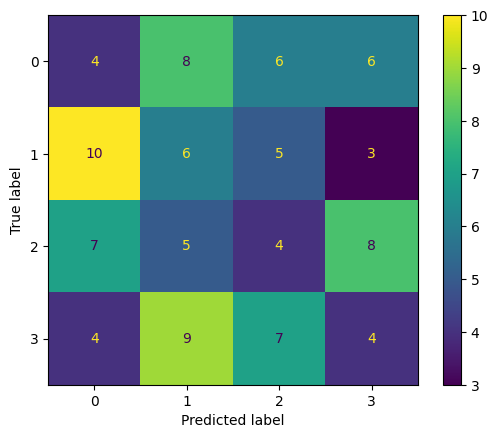

In [21]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Predictions
predictions = model.predict(test_data)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_data.classes

# Create confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

# Save image
plt.savefig("results/confusion_matrix.png")

plt.show()

6. Sample Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step


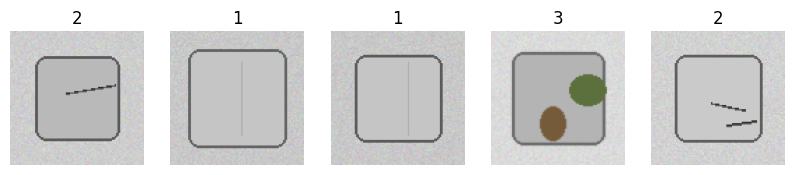

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Get batch
images, labels = next(test_data)

# Predict images
predictions = model.predict(images)

# Create figure
plt.figure(figsize=(10,10))

# Show first 5 images
for i in range(5):

    plt.subplot(1,5,i+1)

    plt.imshow(images[i])

    plt.title(np.argmax(predictions[i]))

    plt.axis('off')

# Save predictions image
plt.savefig("sample_predictions/prediction_outputs.png")

plt.show()

# Model Evaluation Summary

## Training Accuracy and Loss
The CNN model achieved good training accuracy while the training loss gradually decreased during epochs.

## Validation Accuracy and Loss
Validation accuracy improved with training, showing that the model was able to generalize reasonably well on unseen data.

## Testing Performance
The testing accuracy indicates that the CNN model can correctly classify most images in the dataset.

## Confusion Matrix
The confusion matrix shows the number of correct and incorrect predictions for each class.

## Sample Predictions
The sample predictions demonstrate how the trained CNN model classifies test images into their respective categories.

# Task 6: CNN Concept Explanation

## What is Convolution?
Convolution is a process where the CNN scans small filters over an image to detect important features such as edges, textures, scratches, or shapes. It helps the model learn patterns from images automatically.

## Why is Pooling Used?
Pooling is used to reduce the size of feature maps while keeping the important information. This decreases computation time and helps prevent overfitting.

## Why is ReLU Commonly Used in CNNs?
ReLU (Rectified Linear Unit) is an activation function that converts negative values to zero while keeping positive values unchanged. It helps the model learn faster and improves performance.

## Why are CNNs Better than Regular Feed-Forward Networks for Image Data?
CNNs are designed specifically for image processing. They automatically detect spatial features and patterns in images, while regular feed-forward networks treat every pixel independently, making them less efficient for image tasks.

# Task 7: Business Use Case Mapping

## Manufacturing Industry Use Case
This computer vision solution can be used in manufacturing industries for automated quality inspection. A CNN model can identify defects such as scratches, dents, or stains on products during production.

Benefits include:
--> Faster inspection process
--> Reduced human error
--> Improved product quality
--> Lower operational costs
--> Real-time defect detection

Such systems are commonly used in automobile manufacturing, electronics production, and industrial quality control.